1. Introduction
2. Dataset Overview
3. Target Variable: PPM vs UPM
4. System-Level Analysis
5. Time & Seasonality
6. Weather Impact
7. Cost & Duration Analysis
8. Key Insights
9. Capstone Direction

Load & Inspect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/mehakxoxo/Documents/spring_2026/data_practicum/Facility Management Unified Classification Database (FMUCD)/Facility Management Unified Classification Database (FMUCD).csv")
df['WOStartDate'] = pd.to_datetime(df['WOStartDate'], format='mixed', errors='coerce')

df.head()
df.shape
df.info()


/var/folders/29/flsbf9x54_s07dtd6_r_mrvm0000gn/T/ipykernel_40415/1997424791.py:6: DtypeWarning: Columns (3,4,6,10,17,19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/mehakxoxo/Documents/spring_2026/data_practicum/Facility Management Unified Classification Database (FMUCD)/Facility Management Unified Classification Database (FMUCD).csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3731442 entries, 0 to 3731441
Data columns (total 38 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   UniversityID                     int64         
 1   Country                          object        
 2   State/Province                   object        
 3   BuildingID                       object        
 4   BuildingName                     object        
 5   Size                             float64       
 6   Type                             object        
 7   BuiltYear                        float64       
 8   FCI (facility condition index)   float64       
 9   CRV (current replacement value)  float64       
 10  DMC (deferred maintenance cost)  object        
 11  SystemCode                       object        
 12  SystemDescription                object        
 13  SubsystemCode                    object        
 14  SubsystemDescription             o

Target Distribution (PPM vs UPM)

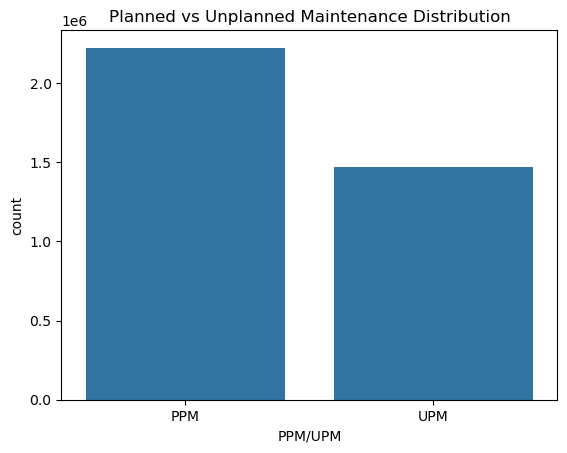

PPM/UPM
PPM    0.602259
UPM    0.397741
Name: proportion, dtype: float64

In [3]:
sns.countplot(x='PPM/UPM', data=df)
plt.title("Planned vs Unplanned Maintenance Distribution")
plt.show()

df['PPM/UPM'].value_counts(normalize=True)


High-Risk Systems

In [4]:
df['Target_UPM'] = (df['PPM/UPM'] == 'UPM').astype(int)

system_risk = df.groupby('SystemDescription')['Target_UPM'].mean().sort_values(ascending=False)
system_risk.head(10)


SystemDescription
Other Site Construction      0.750000
Interior Construction        0.735372
Stairs                       0.670362
Site Preparation             0.655684
Special Construction         0.655389
Furnishings                  0.601773
Interior Finishes            0.590903
Site Electrical Utilities    0.572419
Plumbing                     0.558099
Site Mechanical Utilities    0.515589
Name: Target_UPM, dtype: float64

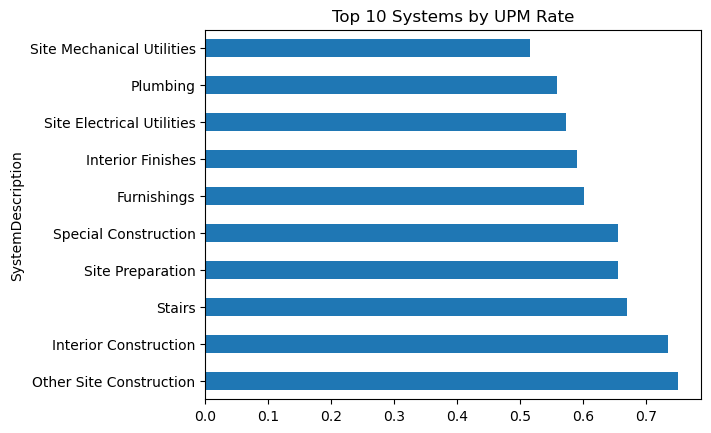

In [5]:
system_risk.head(10).plot(kind='barh', title='Top 10 Systems by UPM Rate')
plt.show()


Seasonal Pattern

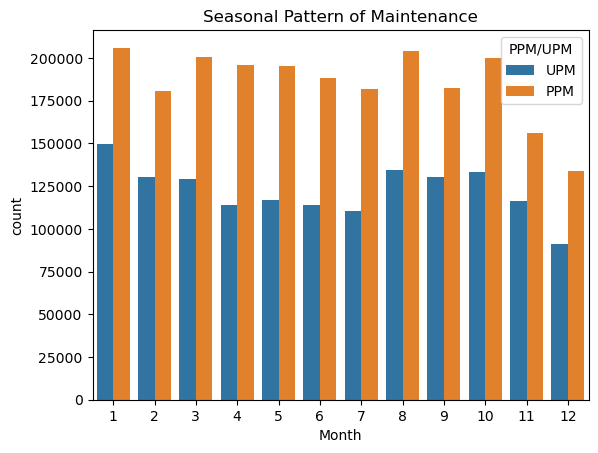

In [6]:
df['Month'] = df['WOStartDate'].dt.month

sns.countplot(x='Month', hue='PPM/UPM', data=df)
plt.title("Seasonal Pattern of Maintenance")
plt.show()


Weather Impact

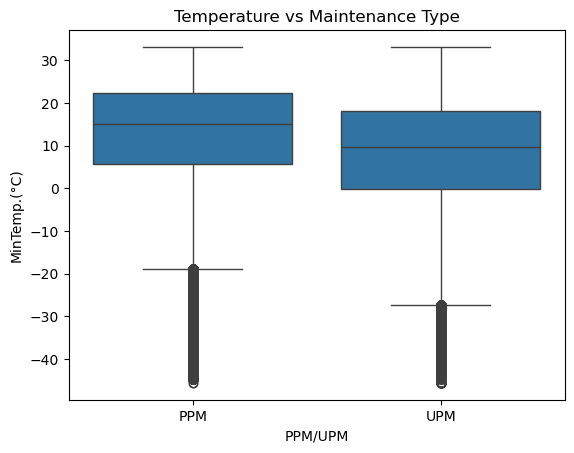

In [7]:
sns.boxplot(x='PPM/UPM', y='MinTemp.(°C)', data=df)
plt.title("Temperature vs Maintenance Type")
plt.show()


In [8]:
weather_cols = ['MinTemp.(°C)','MaxTemp.(°C)','Humidity(%)','WindSpeed(m/s)','Precipitation(mm)','Snow(mm)']
df[weather_cols + ['Target_UPM']].corr()


,MinTemp.(°C),MaxTemp.(°C),Humidity(%),WindSpeed(m/s),Precipitation(mm),Snow(mm),Target_UPM
MinTemp.(°C),1.000000,0.993560,-0.103195,0.042658,0.105318,-0.141500,-0.183068
MaxTemp.(°C),0.993560,1.000000,-0.121458,0.001968,0.098481,-0.146832,-0.178809
Humidity(%),-0.103195,-0.121458,1.000000,-0.049965,0.269803,0.095907,0.099016
WindSpeed(m/s),0.042658,0.001968,-0.049965,1.000000,0.103286,0.052949,-0.016178
Precipitation(mm),0.105318,0.098481,0.269803,0.103286,1.000000,0.087321,-0.010539
Snow(mm),-0.141500,-0.146832,0.095907,0.052949,0.087321,1.000000,0.033442
Target_UPM,-0.183068,-0.178809,0.099016,-0.016178,-0.010539,0.033442,1.000000


Cost Impact

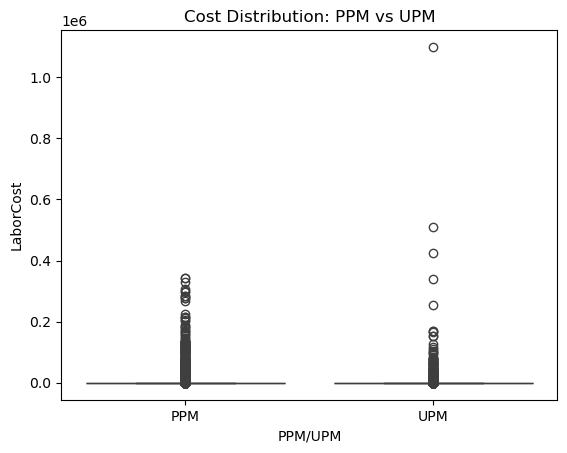

In [9]:
sns.boxplot(x='PPM/UPM', y='LaborCost', data=df)
plt.title("Cost Distribution: PPM vs UPM")
plt.show()


Problem Statement
University campuses manage complex and aging building infrastructures that include critical systems such as HVAC, electrical, plumbing, fire protection, and site facilities. A large portion of maintenance activities are still reactive in nature, occurring as unplanned maintenance (UPM) after equipment failures have already disrupted operations. These emergency breakdowns lead to higher repair costs, safety risks, unplanned downtime, and inefficient allocation of maintenance resources. Although historical maintenance and environmental data are available, they are rarely leveraged to proactively predict failures or to support data-driven decision making. Furthermore, traditional machine learning approaches often act as black boxes, limiting trust and practical adoption by facility managers. Therefore, there is a strong need for an intelligent, transparent, and decision-oriented system that can predict the likelihood of unplanned failures, explain the key factors driving those risks, and translate predictions into actionable maintenance priorities. This project addresses this gap by developing an Explainable Predictive Maintenance and Risk Intelligence Platform that integrates machine learning, weather and temporal analysis, and risk-based prioritization to support proactive and cost-effective facility management in smart university campuses.


## Filter Data: United States - Illinois

In [ ]:
# Filter for United States and Illinois using chunked processing (memory-efficient)
input_path = "/home/sradmin/ai-predictive-maintenance-capstone/FMUCD.csv"
output_path = "/home/sradmin/ai-predictive-maintenance-capstone/data/fmucd_illinois.csv"

chunk_size = 50000  # Process 50k rows at a time
first_chunk = True
total_rows = 0

for chunk in pd.read_csv(input_path, chunksize=chunk_size, low_memory=False):
    # Filter for United States and Illinois
    filtered = chunk[(chunk['Country'] == 'United States') & (chunk['State/Province'] == 'Illinois')]
    
    if len(filtered) > 0:
        # Write header only for first chunk
        filtered.to_csv(output_path, mode='a' if not first_chunk else 'w', 
                       header=first_chunk, index=False)
        first_chunk = False
        total_rows += len(filtered)
    
    print(f"Processed chunk... Total Illinois rows so far: {total_rows}", end='\r')

print(f"\nDone! Exported {total_rows} Illinois records to: {output_path}")

In [ ]:
# Load and preview the filtered Illinois data
df_illinois = pd.read_csv("/home/sradmin/ai-predictive-maintenance-capstone/data/fmucd_illinois.csv")
df_illinois['WOStartDate'] = pd.to_datetime(df_illinois['WOStartDate'], format='mixed', errors='coerce')

print(f"Illinois dataset shape: {df_illinois.shape}")
df_illinois.head()